1. Considere os seguintes sistemas de controle em malha aberta:


- Colete e exiba a resposta desses sistemas a uma entrada degrau;
- Analise a resposta de ambos em função dos polos;
- Obtenha a função de transferência discreta para o período de amostragem T = 0.1s;
- Explicite a função de transferência discreta e a equação a diferença;
- Simule o sistema discreto para uma entrada degrau e compare com a resposta contínua.

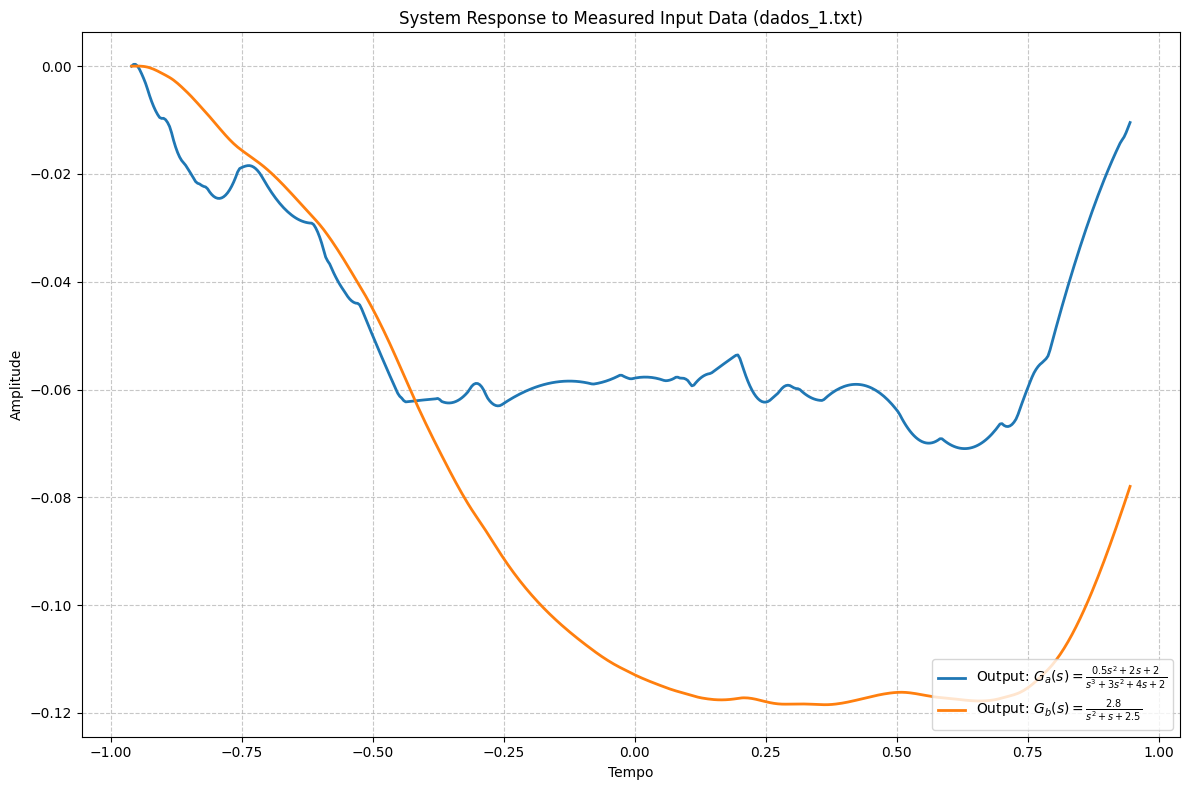

In [1]:
import control as ct
import matplotlib.pyplot as plt
import numpy as np

def load_and_resample_dataset(file_path):
    """
    Carrega e reamostra o dataset de entrada.
    """
    u_data, t_data = np.loadtxt(file_path, delimiter=None, unpack=True)

    sort_idx = np.argsort(t_data)
    t_data: float = t_data[sort_idx]
    u_data: float = u_data[sort_idx]
    t_uniform = np.linspace(t_data[0], t_data[-1], len(t_data))
    u_uniform = np.interp(t_uniform, t_data, u_data)
    
    return t_data, u_data, t_uniform, u_uniform



s = ct.tf('s')

ga = (0.5*s**2 + 2*s + 2) / (s**3 + 3*s**2 + 4*s +2)

gb = 2.8 / (s**2 + s + 2.5)

systems = [ga, gb]

labels = [
    r'$G_a(s) = \frac{0.5s^2 + 2s + 2}{s^3 + 3s^2 + 4s + 2}$',
    r'$G_b(s) = \frac{2.8}{s^2 + s + 2.5}$'
]

t_data, u_data, t_uniform, u_uniform = load_and_resample_dataset('dataset/dados_1.txt')

plt.figure(figsize=(12, 8))
for sys, label in zip(systems, labels):
    time, response = ct.forced_response(sys, T=t_uniform, U=u_uniform)
    plt.plot(time, response, label=f'Output: {label}', linewidth=2)

plt.title(f'System Response to Measured Input Data (dados_1.txt)')
plt.xlabel('Tempo')
plt.ylabel('Amplitude')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

plt.show()

Resposta ao degrau unitário
  G_a: 100 pontos, t ∈ [0, 6.908] s, y_final ≈ 0.998802
  G_b: 100 pontos, t ∈ [0, 13.82] s, y_final ≈ 1.119978


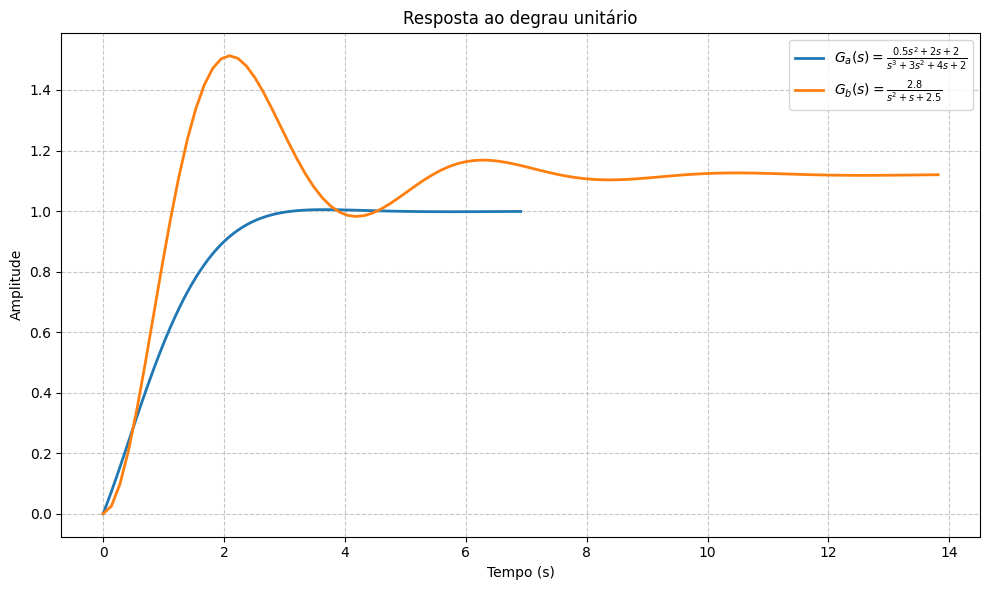

In [2]:
# Resposta ao degrau unitário
fig_step, ax_step = plt.subplots(figsize=(10, 6))
print('Resposta ao degrau unitário')
for sys, label, name in zip(systems, labels, ['G_a', 'G_b']):
    t_step, y_step = ct.step_response(sys)
    ax_step.plot(t_step, y_step, label=label, linewidth=2)
    print(f'  {name}: {len(t_step)} pontos, t ∈ [{t_step[0]:.4g}, {t_step[-1]:.4g}] s, y_final ≈ {y_step[-1]:.6f}')

ax_step.set_title('Resposta ao degrau unitário')
ax_step.set_xlabel('Tempo (s)')
ax_step.set_ylabel('Amplitude')
ax_step.legend(loc='best')
ax_step.grid(True, linestyle='--', alpha=0.7)
fig_step.tight_layout()
plt.show()


## Análise em função dos polos

**Sistema**
$G_a(s)=\dfrac{0.5s^2+2s+2}{s^3+3s^2+4s+2}$ 

O denominador fatora como \($(s+1)(s^2+2s+2)$\), logo os **polos** são \($s=-1$\) (real) e \($s=-1\pm j$\) (par complexo conjugado). Todos no semiplano esquerdo: o sistema é **BIBO estável**. O numerador é $0.5(s+2)^2$, portanto há **dois zeros em** $s=-2$ (mais à esquerda que os polos). O ganho em regime permanente é $G_a(0)=2/2=1$.

O par $s=-1\pm j$ corresponde a um modo **subamortecido** com frequência natural $\omega_n=\sqrt{2}\,\mathrm{rad/s}$ e amortecimento $\zeta=1/\sqrt{2}\approx 0{,}707$ (resposta oscilatória com amortecimento moderado). O polo real em \(-1\) introduz um modo exponencial com a **mesma parte real** que o par complexo, o que tende a **misturar** exponencial e oscilação sem um “batimento” extremo entre escalas de tempo muito diferentes. Os zeros em \(-2\) puxam a resposta no sentido de **reduzir sobressinal** e acelerar o alinhamento ao valor final em relação a um sistema só com o par complexo, porque estão relativamente próximos do eixo imaginário e à esquerda dos polos dominantes.

**Sistema** $G_b(s)=\dfrac{2.8}{s^2+s+2.5}$  
É de **2ª ordem** com polos $s=-0{,}5\pm j1{,}5$. Da forma $s^2+2\zeta\omega_n s+\omega_n^2$ obtém-se $\omega_n=\sqrt{2{,}5}\,\mathrm{rad/s}$ e $\zeta=\dfrac{1}{2\sqrt{2{,}5}}\approx 0{,}316$. Não há zeros finitos: dinâmica puramente do par de polos. O ganho DC é $G_b(0)=2{,}8/2{,}5=1{,}12$.

Com $\zeta<0{,}5$, o sistema é **mais subamortecido** que o modo oscilatório de $G_a$: espera-se **maior sobressinal** e oscilações mais acentuadas antes do estabelecimento. A parte real dos polos é $-0{,}5$, **menos negativa** que a de $(G_a) ((-1))$, logo os modos de $(G_b)$ decaem em geral **mais devagar** que os de \(G_a\) (resposta mais “lenta” em termos de envoltória).

**Comparando os dois**  
Ambos são estáveis e exibem oscilação devido aos polos complexos, mas **$(G_b)$** tem **menor amortecimento relativo** ($(\zeta) menor$) e **polos mais próximos do eixo imaginário**, o que explica maior oscilação e estabelecimento mais lento; **$(G_a)$** combina três polos (um real + um par complexo) com **dois zeros** que moldam a forma da resposta e ganho DC unitário, enquanto **$(G_b)$** tende a um valor final **ligeiramente acima de 1** por causa do ganho estático.


In [3]:
import numpy as np

# Discretização ZOH (equivalência ao retentor de ordem zero)
Ts = 0.1  # s
ga_d = ct.c2d(ga, Ts, method='zoh')
gb_d = ct.c2d(gb, Ts, method='zoh')

print(f'Funções de transferência discretas (ZOH), Ts = {Ts} s\n')
print('G_a(z) =')
print(ga_d)
print()
print('G_b(z) =')
print(gb_d)


def _poly_z_str(coeffs):
    """Coeficientes em potências decrescentes de z: c0*z^n + c1*z^(n-1) + ..."""
    c = np.asarray(coeffs, dtype=float)
    deg = len(c) - 1
    s = ''
    first = True
    for i, ak in enumerate(c):
        if abs(ak) < 1e-12:
            continue
        p = deg - i
        if p == 0:
            t = f'{abs(ak):.6g}'
        elif p == 1:
            t = f'{abs(ak):.6g} z'
        else:
            t = f'{abs(ak):.6g} z^{p}'
        if first:
            s += ('-' if ak < 0 else '') + t
            first = False
        else:
            s += (' + ' if ak >= 0 else ' - ') + t
    return s if s else '0'


def explicit_Gz_and_diffeq(label, sys_d):
    """G(z)=N/D e sum_i den[i] y[k-i] = sum_j num[j] u[k-1-j] (causal)."""
    num = np.array(sys_d.num[0][0], dtype=float)
    den = np.array(sys_d.den[0][0], dtype=float)
    print(f'\n--- {label} ---')
    print('Forma racional explícita (potências decrescentes de z):')
    print(f'  {label}(z) = ({_poly_z_str(num)}) / ({_poly_z_str(den)})')

    lhs = f'{den[0]:.6g} y[k]'
    for i in range(1, len(den)):
        a = den[i]
        lhs += f' {"+" if a >= 0 else "-"} {abs(a):.6g} y[k-{i}]'

    rhs = f'{num[0]:.6g} u[k-1]'
    for j in range(1, len(num)):
        a = num[j]
        rhs += f' {"+" if a >= 0 else "-"} {abs(a):.6g} u[k-{j+1}]'

    print('Equação às diferenças (relação causal padrão Y(z)D(z) = U(z)N(z)):')
    print(f'  {lhs} = {rhs}')


explicit_Gz_and_diffeq('G_a', ga_d)
explicit_Gz_and_diffeq('G_b', gb_d)


Funções de transferência discretas (ZOH), Ts = 0.1 s

G_a(z) =
<TransferFunction>: sys[25]$sampled
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']
dt = 0.1

   0.05226 z^2 - 0.08553 z + 0.035
  ----------------------------------
  z^3 - 2.705 z^2 + 2.448 z - 0.7408

G_b(z) =
<TransferFunction>: sys[33]$sampled
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']
dt = 0.1

   0.01352 z + 0.01307
  ----------------------
  z^2 - 1.881 z + 0.9048

--- G_a ---
Forma racional explícita (potências decrescentes de z):
  G_a(z) = (0.0522563 z^2 - 0.0855332 z + 0.0349991) / (1 z^3 - 2.70547 z^2 + 2.44801 z - 0.740818)
Equação às diferenças (relação causal padrão Y(z)D(z) = U(z)N(z)):
  1 y[k] - 2.70547 y[k-1] + 2.44801 y[k-2] - 0.740818 y[k-3] = 0.0522563 u[k-1] - 0.0855332 u[k-2] + 0.0349991 u[k-3]

--- G_b ---
Forma racional explícita (potências decrescentes de z):
  G_b(z) = (0.0135168 z + 0.0130733) / (1 z^2 - 1.8811 z + 0.904837)
Equação às diferenças (relação causal padrão Y(z)D(z) = U(z)N(z)):
  1 y[k]

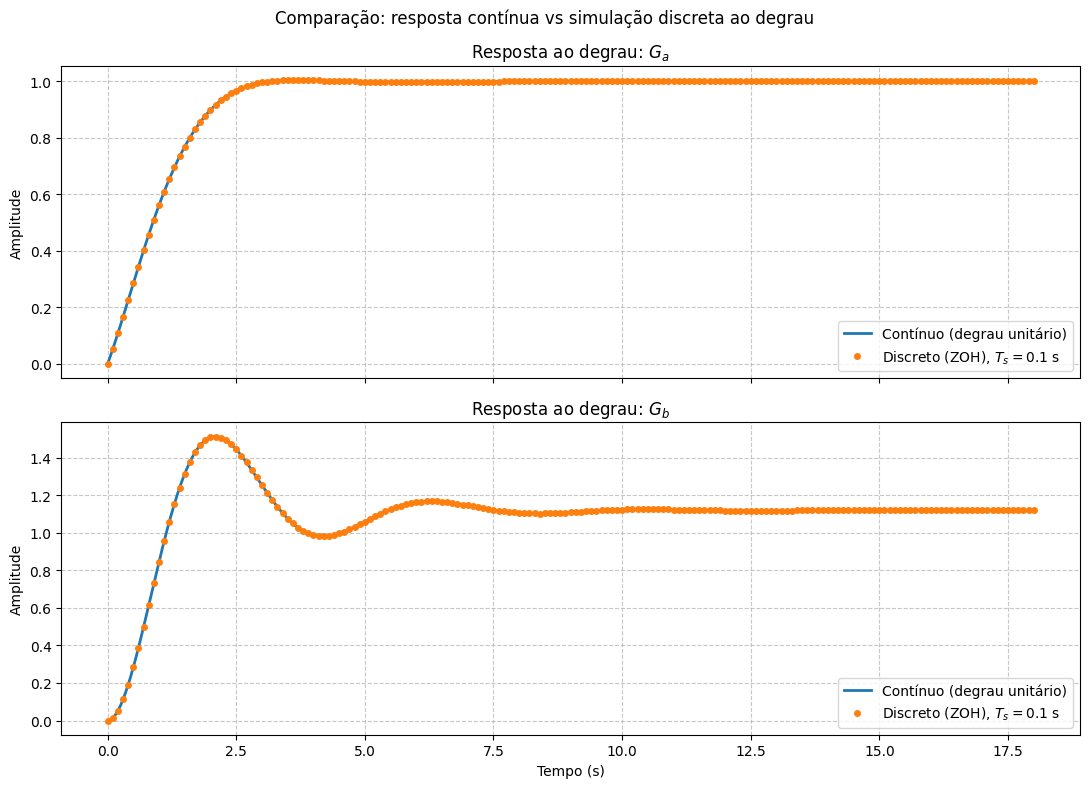

In [4]:
# Mesmo horizonte para ambos; contínuo denso, discreto nos instantes k*Ts
t_end = 18.0
t_cont = np.linspace(0.0, t_end, 2000)
t_disc = np.arange(0.0, t_end + Ts / 2, Ts)

fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True)
pairs = [(ga, ga_d, r'$G_a$'), (gb, gb_d, r'$G_b$')]

for ax, (sys_c, sys_d, name) in zip(axes, pairs):
    tc, yc = ct.step_response(sys_c, T=t_cont)
    td, yd = ct.step_response(sys_d, T=t_disc)
    ax.plot(tc, yc, '-', color='C0', linewidth=2, label='Contínuo (degrau unitário)')
    ax.plot(td, yd, 'o', color='C1', markersize=4, label=f'Discreto (ZOH), $T_s={Ts}$ s')
    ax.set_ylabel('Amplitude')
    ax.set_title(f'Resposta ao degrau: {name}')
    ax.grid(True, linestyle='--', alpha=0.7)
    ax.legend(loc='lower right')

axes[-1].set_xlabel('Tempo (s)')
fig.suptitle('Comparação: resposta contínua vs simulação discreta ao degrau')
plt.tight_layout()
plt.show()


2. Ainda considerando os itens a) e b) da questão anterior faça:

- Gere valores simulados a partir da equação a diferença para uma entrada degrau e para uma entrada caracterizada por uma distribuição uniforme, com valores no intervalo [-1,1], com média zero, sem ruídos, equivalente a 100 passos de simulação (y(1) a y(100)).
- Utilizando o estimador de mínimos quadrados (EMQ), calcule modelos de 1 e 5 ordem para representar o sistema. Para cada modelo, calcule o vetor de resíduos e seu valor médio. Plote os resíduos e seu valor médio e faça uma análise (resíduo = y(k) - y_chapeu(k)).
- Acrescente ruído (gaussiano, desvio padrão 0.05, média zero) ao sistema de duas formas:
  - y(k) = y(k) + e(k) ->Ruído Dinâmico (adicionado a cada amostragem)
  - Y(k) = Y(k) + E(k) ->Ruído interno de sensor (adicionado de uma vez ao sistema)
- Refaça 100 vezes a identificação do sistema com ordem 3 em cada situação usando diferentes realizações do ruído. Calcule a média e desvio dos parâmetros. (em cada uma das 100 identificações).
  

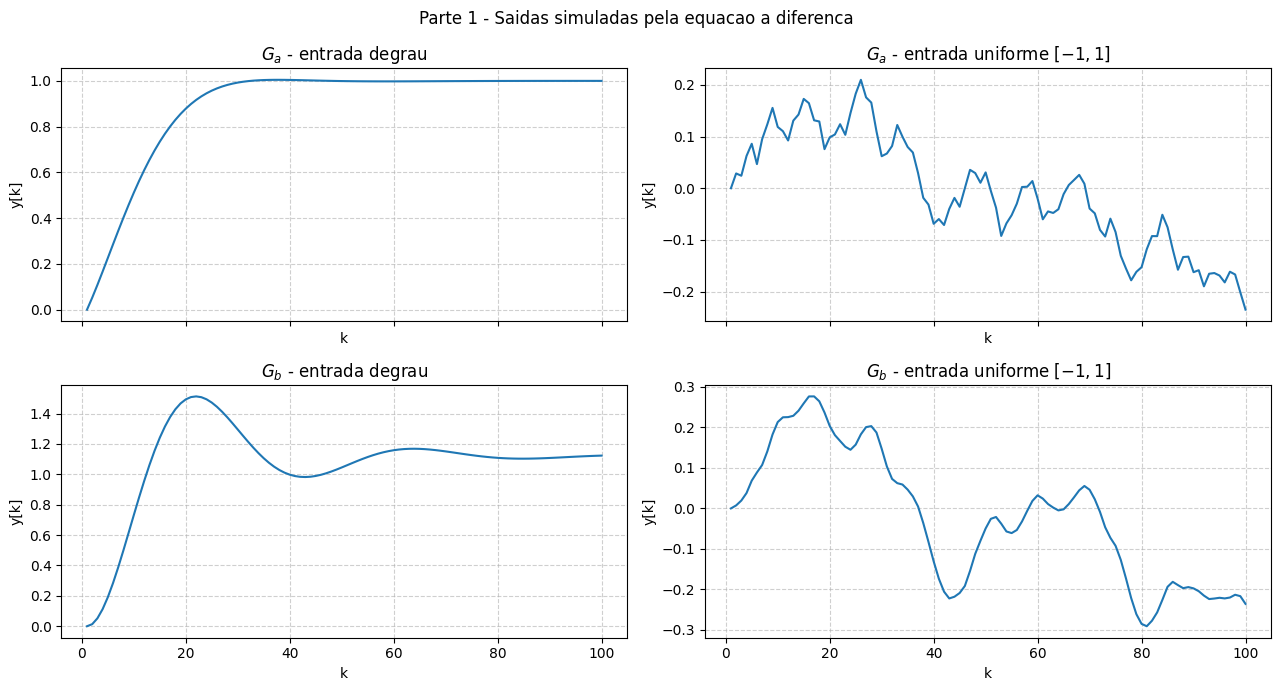

In [5]:
# ============================================================
# Parte 1 - Simulacao das equacoes a diferenca (100 amostras, sem ruido)
# ============================================================
import numpy as np
import matplotlib.pyplot as plt

N = 100
rng_in = np.random.default_rng(seed=42)

# Coeficientes vindos de ga_d e gb_d (discretizacao ZOH com Ts = 0.1 s)
# Convencao:  den[0]*y[k] + den[1]*y[k-1] + ... = num[0]*u[k-1] + num[1]*u[k-2] + ...
num_a = np.array([ 0.0522563, -0.0855332,  0.0349991])
den_a = np.array([ 1.0,       -2.70547,    2.44801,   -0.740818])

num_b = np.array([ 0.0135168,  0.0130733])
den_b = np.array([ 1.0,       -1.8811,     0.904837])


def simulate_diffeq(num, den, u):
    """
    Resolve a equacao a diferenca isolando y[k]:
        y[k] = (sum num[j]*u[k-1-j] - sum den[i]*y[k-i]) / den[0]
    Considera condicoes iniciais nulas (y e u com indice negativo = 0).
    """
    N = len(u)
    y = np.zeros(N)
    na = len(den) - 1     # numero de termos y[k-i] no regressor
    nb = len(num)         # numero de termos u[k-1-j]
    for k in range(N):
        acc = 0.0
        for j in range(nb):              # entradas atrasadas
            idx = k - (j + 1)
            if idx >= 0:
                acc += num[j] * u[idx]
        for i in range(1, na + 1):       # saidas anteriores (passam pro outro lado)
            idx = k - i
            if idx >= 0:
                acc -= den[i] * y[idx]
        y[k] = acc / den[0]
    return y


# Entradas (100 amostras)
u_step = np.ones(N)
u_unif = rng_in.uniform(-1.0, 1.0, size=N)

# Saidas simuladas
y_a_step = simulate_diffeq(num_a, den_a, u_step)
y_a_unif = simulate_diffeq(num_a, den_a, u_unif)
y_b_step = simulate_diffeq(num_b, den_b, u_step)
y_b_unif = simulate_diffeq(num_b, den_b, u_unif)

k_axis = np.arange(1, N + 1)   # y(1) ... y(100)

fig, axes = plt.subplots(2, 2, figsize=(13, 7), sharex=True)
axes[0, 0].plot(k_axis, y_a_step); axes[0, 0].set_title(r"$G_a$ - entrada degrau")
axes[0, 1].plot(k_axis, y_a_unif); axes[0, 1].set_title(r"$G_a$ - entrada uniforme $[-1,1]$")
axes[1, 0].plot(k_axis, y_b_step); axes[1, 0].set_title(r"$G_b$ - entrada degrau")
axes[1, 1].plot(k_axis, y_b_unif); axes[1, 1].set_title(r"$G_b$ - entrada uniforme $[-1,1]$")
for ax in axes.ravel():
    ax.set_xlabel("k"); ax.set_ylabel("y[k]")
    ax.grid(True, linestyle="--", alpha=0.6)
fig.suptitle("Parte 1 - Saidas simuladas pela equacao a diferenca")
fig.tight_layout()
plt.show()


EMQ - $G_a$ (ordem real = 3) com entrada uniforme $[-1,1]$
 ordem     media residuo     RMS residuo    # parametros
     1       -7.0355e-04      4.5700e-03               2
     2        1.6075e-05      4.9336e-05               4
     3        2.6414e-17      6.9462e-16               6
     4       -7.5352e-18      1.5023e-16               8
     5        5.5968e-18      1.5959e-16              10


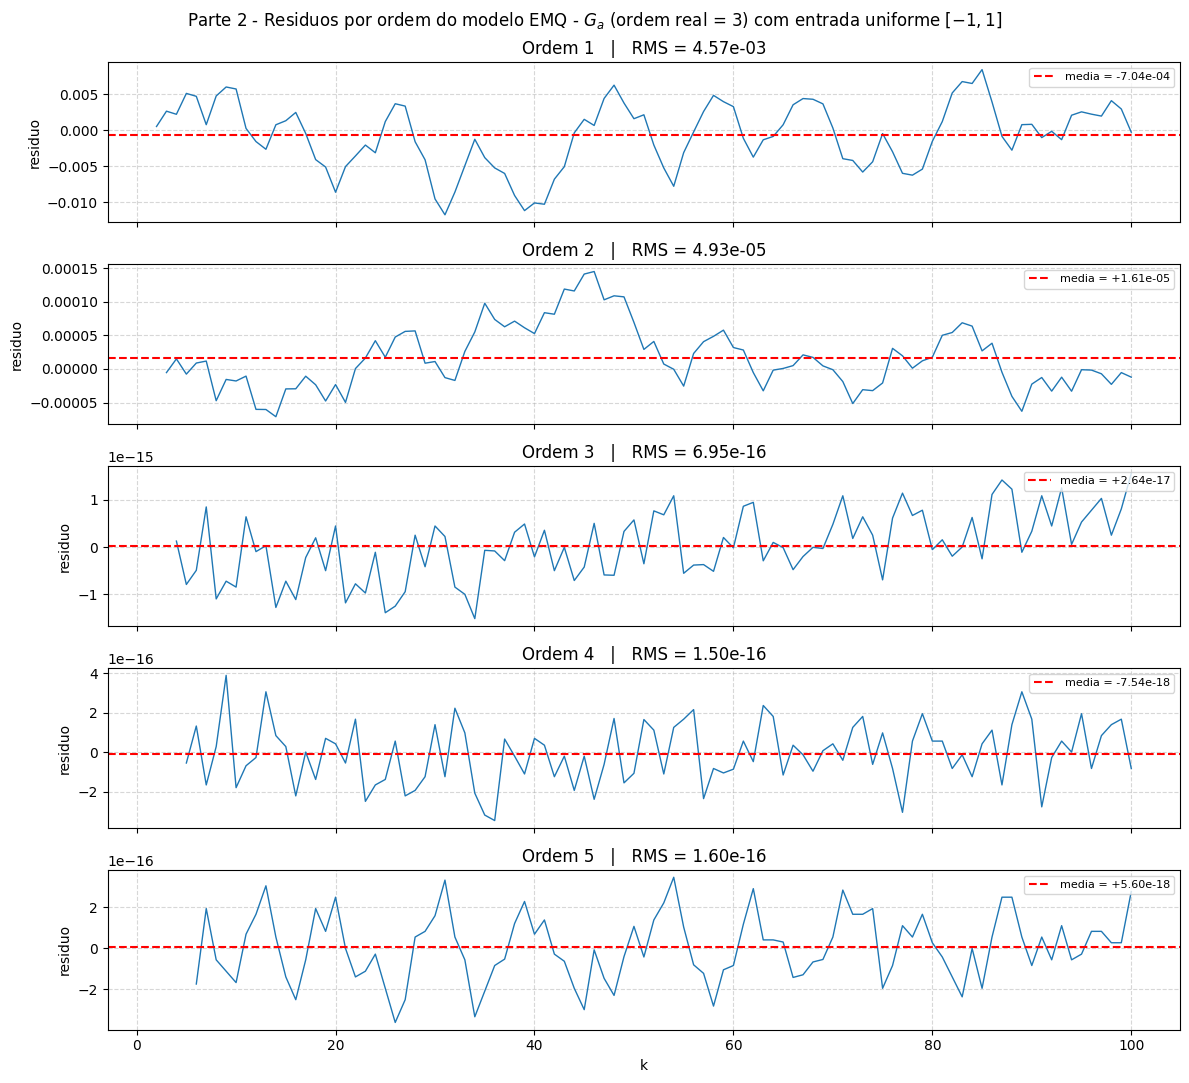

In [6]:
# ============================================================
# Parte 2 - EMQ para modelos de ordem 1 a 5 (residuos + valor medio)
# ============================================================
# Modelo ARX de ordem n:
#   y[k] = a1 y[k-1] + ... + an y[k-n] + b1 u[k-1] + ... + bn u[k-n]
# Monta Phi (regressor) com as n amostras anteriores e resolve theta por lstsq.

def build_regressor(y, u, n):
    """Monta Phi (N-n, 2n) e Y (N-n,) para regressao ARX de ordem n."""
    N = len(y)
    Phi = np.zeros((N - n, 2 * n))
    Y = np.zeros(N - n)
    for k in range(n, N):
        linha = [y[k - i] for i in range(1, n + 1)] + [u[k - j] for j in range(1, n + 1)]
        Phi[k - n] = linha
        Y[k - n] = y[k]
    return Phi, Y


def lse_fit(y, u, n):
    """Estimador de Minimos Quadrados: theta = (Phi^T Phi)^-1 Phi^T Y."""
    Phi, Y = build_regressor(y, u, n)
    theta, *_ = np.linalg.lstsq(Phi, Y, rcond=None)
    y_hat = Phi @ theta
    res = Y - y_hat                        # residuo = y - y_chapeu
    return theta, res, y_hat


# Identificacao usando a saida de G_a com entrada uniforme (entrada persistente)
y_id = y_a_unif
u_id = u_unif
nome = r"$G_a$ (ordem real = 3) com entrada uniforme $[-1,1]$"

ordens = range(1, 6)
fig, axes = plt.subplots(len(ordens), 1, figsize=(12, 11), sharex=True)

print(f"EMQ - {nome}")
print(f"{'ordem':>6}{'media residuo':>18}{'RMS residuo':>16}{'# parametros':>16}")
for ax, n in zip(axes, ordens):
    theta, res, _ = lse_fit(y_id, u_id, n)
    media = res.mean()
    rms = np.sqrt((res ** 2).mean())
    k_res = np.arange(n + 1, N + 1)        # residuo comeca em k = n+1
    ax.plot(k_res, res, linewidth=1, color="C0")
    ax.axhline(media, color="red", linestyle="--",
               label=f"media = {media:+.2e}")
    ax.set_title(f"Ordem {n}   |   RMS = {rms:.2e}")
    ax.set_ylabel("residuo")
    ax.legend(loc="upper right", fontsize=8)
    ax.grid(True, linestyle="--", alpha=0.5)
    print(f"{n:>6d}{media:>18.4e}{rms:>16.4e}{2*n:>16d}")

axes[-1].set_xlabel("k")
fig.suptitle(f"Parte 2 - Residuos por ordem do modelo EMQ - {nome}")
fig.tight_layout()
plt.show()


Monte Carlo - 100 realizacoes, ordem 3, sigma = 0.05

param       verdadeiro     media dyn    desvio dyn    media sensor   desvio sensor
$\hat a_1$      2.705470      2.662164      0.086356        0.320955        0.099932
$\hat a_2$     -2.448010     -2.365966      0.172994        0.269455        0.104836
$\hat a_3$      0.740818      0.701391      0.088212        0.288075        0.082681
$\hat b_1$      0.052256      0.053907      0.009365        0.050902        0.009960
$\hat b_2$     -0.085533     -0.083036      0.010208        0.042368        0.011984
$\hat b_3$      0.034999      0.033350      0.010442        0.028564        0.011366


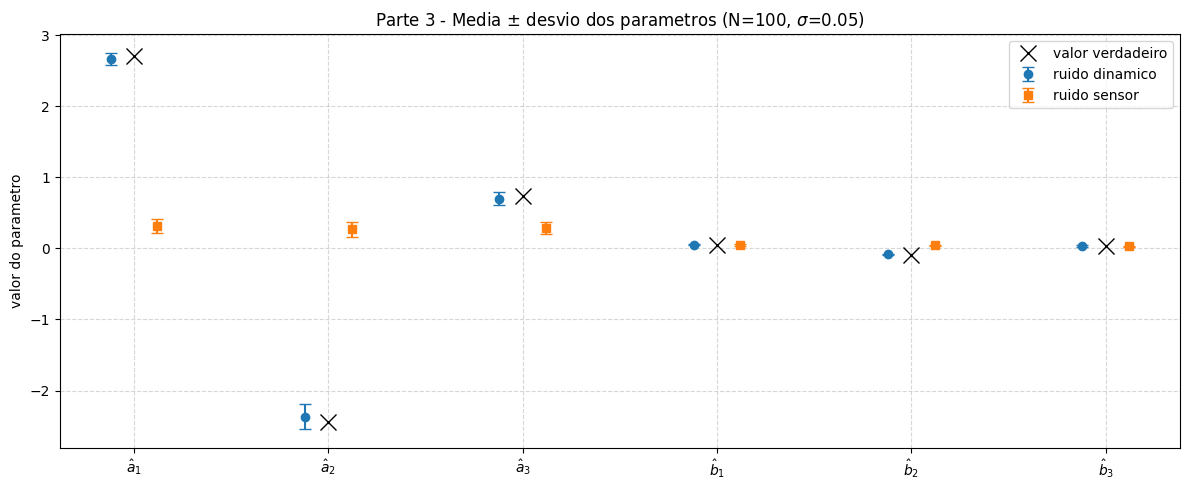

In [7]:
# ============================================================
# Parte 3 - Monte Carlo: 100 realizacoes, ordem 3
#   Caso A: ruido DINAMICO  -> injetado dentro do loop (realimenta)
#   Caso B: ruido de SENSOR -> somado na saida ja simulada (nao realimenta)
# ============================================================
sigma   = 0.05
N_MC    = 100
n_model = 3


def simulate_with_dynamic_noise(num, den, u, sigma, rng):
    """Mesma simulacao da Parte 1, porem somando e[k] em cada passo."""
    N = len(u)
    y = np.zeros(N)
    na = len(den) - 1
    nb = len(num)
    e = rng.normal(0.0, sigma, size=N)
    for k in range(N):
        acc = 0.0
        for j in range(nb):
            idx = k - (j + 1)
            if idx >= 0:
                acc += num[j] * u[idx]
        for i in range(1, na + 1):
            idx = k - i
            if idx >= 0:
                acc -= den[i] * y[idx]
        y[k] = acc / den[0] + e[k]         # ruido realimenta no proximo passo
    return y


# Entrada unica (uniforme persistente) - so o ruido varia entre iteracoes
rng_mc  = np.random.default_rng(seed=123)
u_mc    = rng_mc.uniform(-1.0, 1.0, size=N)
y_limpo = simulate_diffeq(num_a, den_a, u_mc)    # usada para o caso sensor

thetas_dyn = np.zeros((N_MC, 2 * n_model))
thetas_sen = np.zeros((N_MC, 2 * n_model))

for i in range(N_MC):
    rng_i = np.random.default_rng(seed=1000 + i)

    # Caso A - ruido dinamico
    y_dyn = simulate_with_dynamic_noise(num_a, den_a, u_mc, sigma, rng_i)
    thetas_dyn[i], *_ = lse_fit(y_dyn, u_mc, n_model)

    # Caso B - ruido de sensor (somado uma vez na saida limpa)
    E = rng_i.normal(0.0, sigma, size=N)
    y_sen = y_limpo + E
    thetas_sen[i], *_ = lse_fit(y_sen, u_mc, n_model)

# Valores "verdadeiros" no formato [a1, a2, a3, b1, b2, b3]
# onde y[k] = a1 y[k-1] + ... + b1 u[k-1] + ...
theta_true = np.concatenate([-den_a[1:], num_a])
labels_param = [r"$\hat a_1$", r"$\hat a_2$", r"$\hat a_3$",
                r"$\hat b_1$", r"$\hat b_2$", r"$\hat b_3$"]

print(f"Monte Carlo - {N_MC} realizacoes, ordem {n_model}, sigma = {sigma}\n")
print(f"{'param':<8}{'verdadeiro':>14}{'media dyn':>14}{'desvio dyn':>14}"
      f"{'media sensor':>16}{'desvio sensor':>16}")
for j in range(2 * n_model):
    print(f"{labels_param[j]:<8}"
          f"{theta_true[j]:>14.6f}"
          f"{thetas_dyn[:, j].mean():>14.6f}{thetas_dyn[:, j].std():>14.6f}"
          f"{thetas_sen[:, j].mean():>16.6f}{thetas_sen[:, j].std():>16.6f}")

# Visualizacao: media +/- desvio de cada parametro nos dois casos
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(2 * n_model)
ax.errorbar(x - 0.12, thetas_dyn.mean(axis=0), yerr=thetas_dyn.std(axis=0),
            fmt="o", capsize=4, label="ruido dinamico")
ax.errorbar(x + 0.12, thetas_sen.mean(axis=0), yerr=thetas_sen.std(axis=0),
            fmt="s", capsize=4, label="ruido sensor")
ax.plot(x, theta_true, "kx", markersize=12, label="valor verdadeiro")
ax.set_xticks(x); ax.set_xticklabels(labels_param)
ax.set_ylabel("valor do parametro")
ax.set_title(fr"Parte 3 - Media $\pm$ desvio dos parametros (N={N_MC}, $\sigma$={sigma})")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.5)
fig.tight_layout()
plt.show()
